# Credit Risk Prediction

Predicting the probability of default on consumer loans (Credit Risk Dataset, Kaggle).

**Objective**: to classify `loan_status` (0 = repaid, 1 = default) based on the characteristics of the applicant and the loan.

**Methodological note on design**: `loan_grade` and `loan_int_rate` are assigned by the bank *after* it has carried out its own assessment of the customer’s risk. Including them in the training risks causing the model to ‘copy’ a risk assessment already made by others, rather than learning it from the raw customer data. For this reason, we compare two scenarios:
- **full**: all available features, including `loan_grade`/`loan_int_rate`
- **clean**: only features known *before* the risk assessment 



In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from data_prep import prepare_dataset, get_feature_sets, load_data, TARGET_COL
from modeling import split_data, train_and_evaluate, print_results, MODELS

sns.set_style("whitegrid")
%matplotlib inline

## 1. Loading and initial exploration

In [2]:
df_raw=pd.read_csv(r"C:\Users\berto\Downloads\credit_risk_dataset.csv\credit_risk_dataset.csv")
print(df_raw.shape)
df_raw.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df_raw.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
df_raw.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## 2. Outliers in age and work experience

The dataset is known to contain clearly incorrect values for `person_age` and `person_emp_length`
(e.g. age > 100 years, work experience > 100 years). We examine these before deciding how to handle them.

age > 100: 5
emp_length > 60: 2


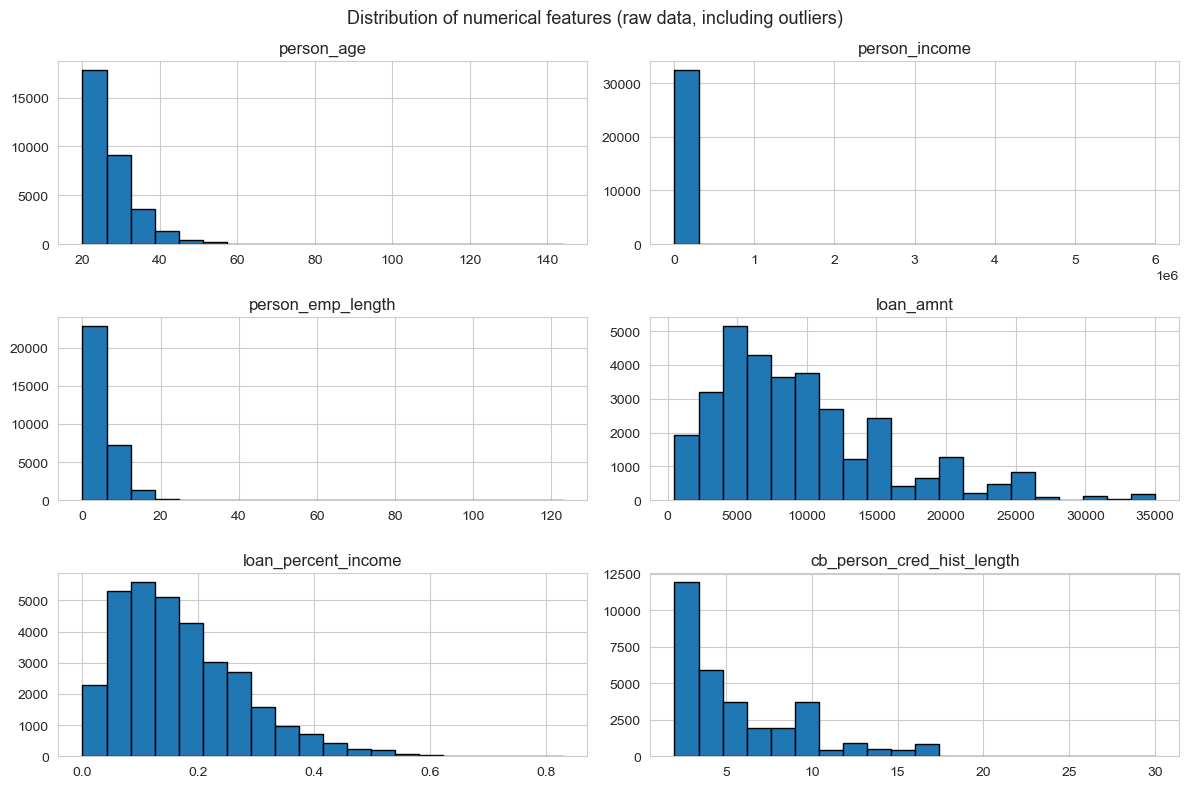

In [5]:
print("age > 100:", (df_raw["person_age"] > 100).sum())
print("emp_length > 60:", (df_raw["person_emp_length"] > 60).sum())

df_raw[["person_age", "person_income", "person_emp_length", "loan_amnt",
        "loan_percent_income", "cb_person_cred_hist_length"]].hist(
    bins=20, edgecolor="black", figsize=(12, 8)
)
plt.suptitle("Distribution of numerical features (raw data, including outliers)", fontsize=13)
plt.tight_layout()
plt.show()

The cleaning thresholds (`MAX_PLAUSIBLE_AGE=100`, `MAX_PLAUSIBLE_EMP_LENGTH=60`) are defined in `src/data_prep.py`.

In [6]:
df = prepare_dataset(r"C:\Users\berto\Downloads\credit_risk_dataset.csv\credit_risk_dataset.csv")
print(df.shape)
df.head()

print("Before:", df_raw["person_age"].max(), df_raw["person_emp_length"].max(), df_raw["person_income"].max())
print("After: ", df["person_age"].max(), df["person_emp_length"].max(), df["person_income"].max())
print("Rows dropped:", len(df_raw) - len(df))

Removed 902 rows (2.77%) due to outliers on age/emp_length
(31679, 15)
Before: 144 123.0 6000000
After:  94 41.0 2039784
Rows dropped: 902


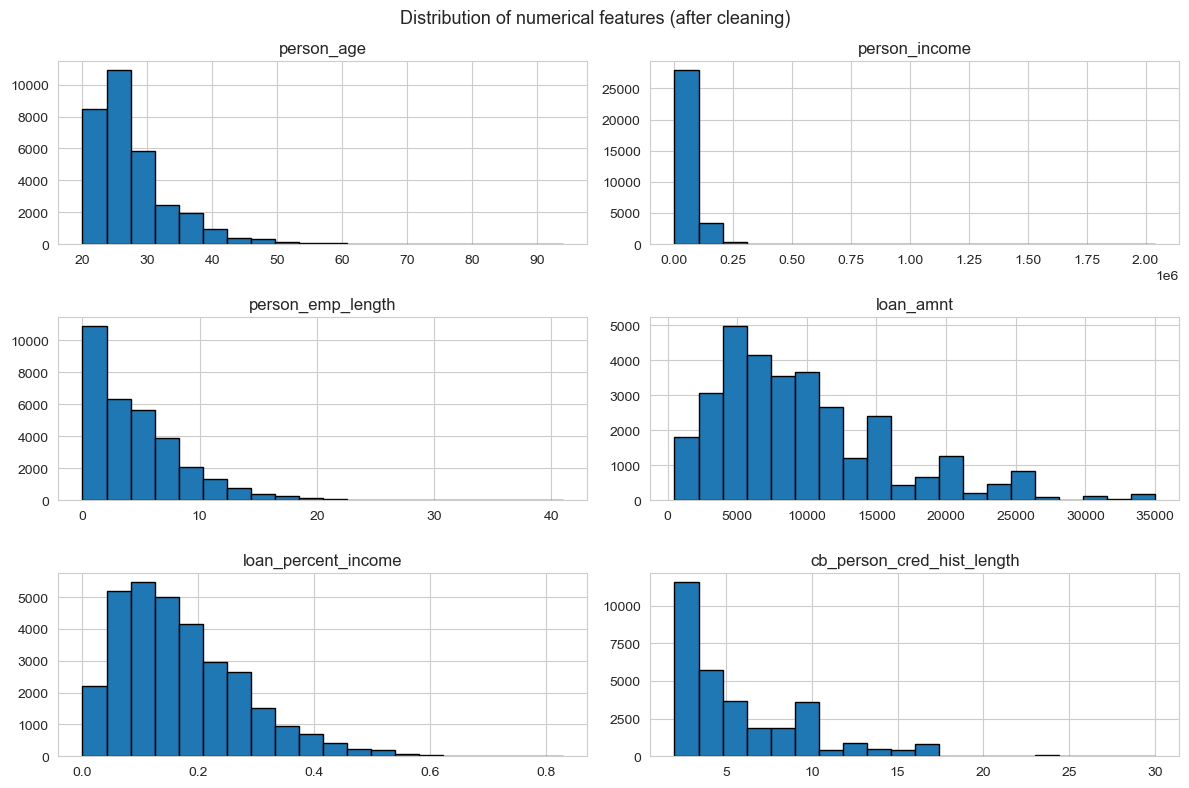

In [7]:
df[["person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_percent_income", "cb_person_cred_hist_length"]].hist(
    bins=20, edgecolor="black", figsize=(12, 8)
)
plt.suptitle("Distribution of numerical features (after cleaning)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Categorical Variables and Target

In [8]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print("Categorical Variables:")
    print(f"\n --- {col}---")
    print(df[col].value_counts())



Categorical Variables:

 --- person_home_ownership---
person_home_ownership
RENT        16072
MORTGAGE    13090
OWN          2410
OTHER         107
Name: count, dtype: int64
Categorical Variables:

 --- loan_intent---
loan_intent
EDUCATION            6288
MEDICAL              5897
VENTURE              5553
PERSONAL             5367
DEBTCONSOLIDATION    5064
HOMEIMPROVEMENT      3510
Name: count, dtype: int64
Categorical Variables:

 --- loan_grade---
loan_grade
A    10370
B    10183
C     6319
D     3555
E      952
F      236
G       64
Name: count, dtype: int64
Categorical Variables:

 --- cb_person_default_on_file---
cb_person_default_on_file
N    26051
Y     5628
Name: count, dtype: int64


In [9]:
print(f"Target Column: {TARGET_COL}")
print(df[TARGET_COL].value_counts(normalize=True))

Target Column: loan_status
loan_status
0    0.784558
1    0.215442
Name: proportion, dtype: float64


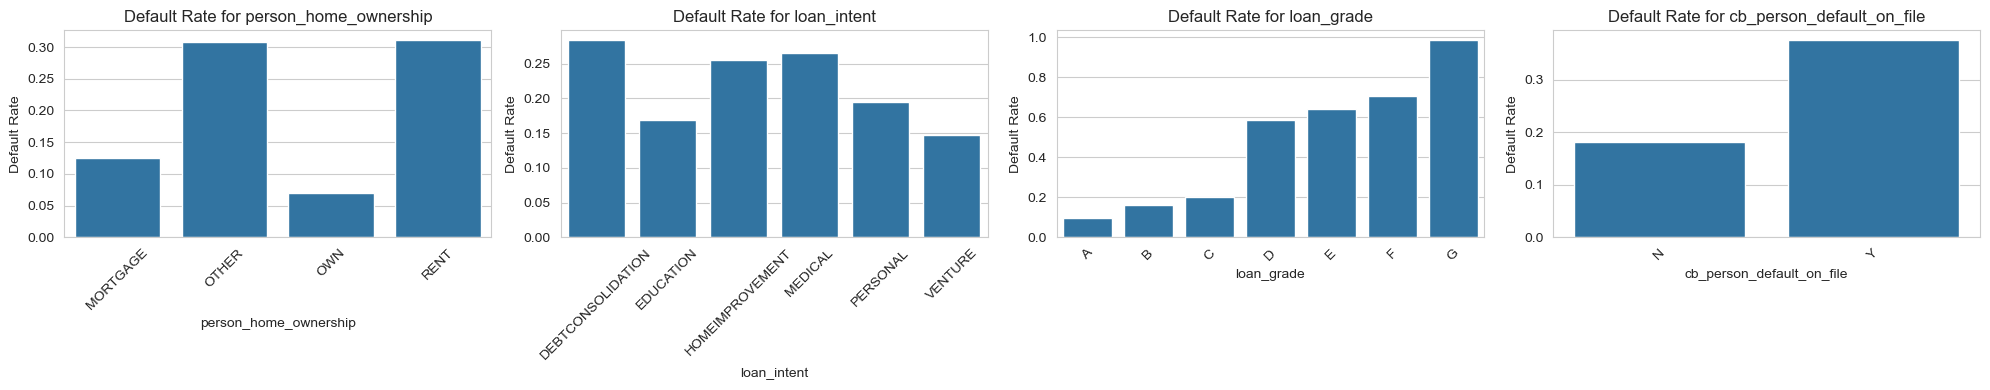

In [10]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 4))
for ax, col in zip(axes, cat_cols):
    sns.barplot(
        data=df.groupby(col)[TARGET_COL].mean().reset_index(),
        x=col, y=TARGET_COL, ax=ax
    )
    ax.set_title(f"Default Rate for {col}")
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Correlations between numerical features

We check for any redundancy or multicollinearity before moving on to modelling.

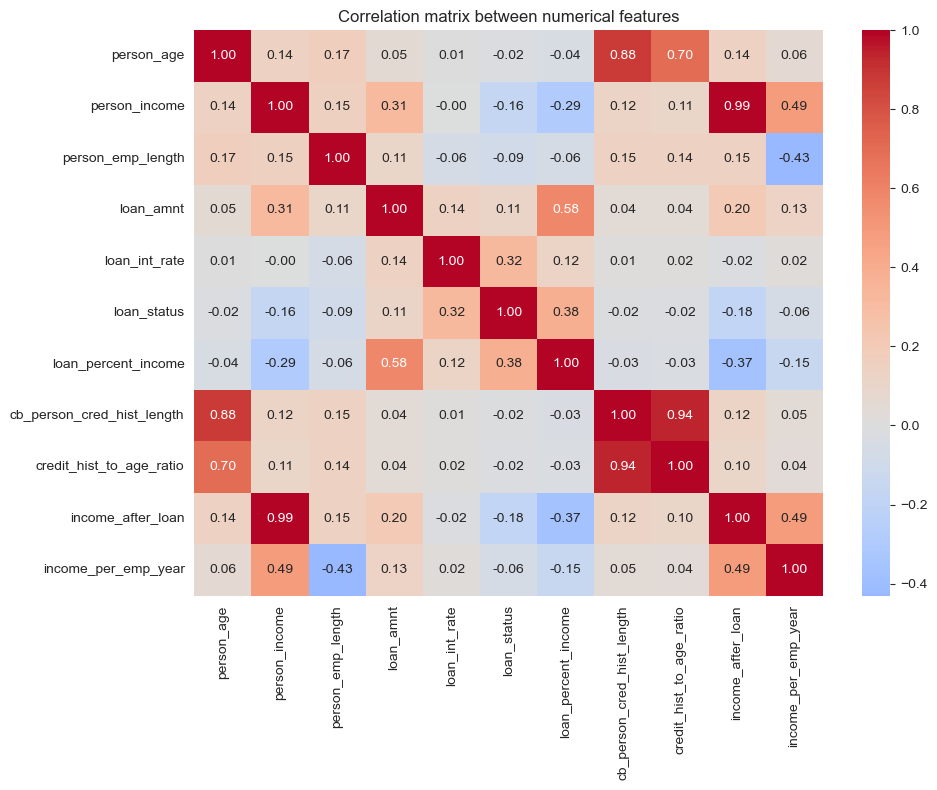

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix between numerical features")
plt.tight_layout()
plt.show()

## 5. Stratified train/test split

A split stratified by target to preserve the class imbalance in both sets,
plus stratified cross-validation (5-fold) on the training set for hyperparameter tuning.

In [12]:
full_features, clean_features = get_feature_sets(df)
print("Full feature set:", full_features)
print("\nClean feature set (without leakage):", clean_features)

Full feature set: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'credit_hist_to_age_ratio', 'income_after_loan', 'income_per_emp_year']

Clean feature set (without leakage): ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'credit_hist_to_age_ratio', 'income_after_loan', 'income_per_emp_year']


## 6. Model training and comparison

Let’s compare Logistic Regression (interpretable baseline), Random Forest and XGBoost,
each on both feature sets (`full` vs `clean`), using GridSearchCV on ROC-AUC.

In [13]:
all_results = {}

for feature_set_name, feature_cols in [("clean", clean_features), ("full", full_features)]:
    X_train, X_test, y_train, y_test = split_data(df, feature_cols)

    for model_name in MODELS:
        key = f"{model_name}__{feature_set_name}"
        print(f"\n\n### Training {key} ###")
        model, results = train_and_evaluate(
            X_train, X_test, y_train, y_test, feature_cols, model_name
        )
        print_results(results)
        all_results[key] = {"model": model, "results": results}



### Training logistic_regression__clean ###

Model: logistic_regression
Best Hyperparameters: {'clf__C': 0.1}
ROC-AUC (CV):   0.8053
ROC-AUC (test): 0.8094
PR-AUC  (test): 0.6230

Classification report (test):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      4971
           1       0.44      0.71      0.54      1365

    accuracy                           0.74      6336
   macro avg       0.67      0.73      0.68      6336
weighted avg       0.80      0.74      0.76      6336

Confusion matrix (test):
[[3731 1240]
 [ 397  968]]


### Training random_forest__clean ###

Model: random_forest
Best Hyperparameters: {'clf__max_depth': None, 'clf__n_estimators': 400}
ROC-AUC (CV):   0.8716
ROC-AUC (test): 0.8794
PR-AUC  (test): 0.7820

Classification report (test):
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      4971
           1       0.89      0.52      0.66      1365

    accura

## 7. Summary comparison

In [14]:
summary = pd.DataFrame([
    {
        "model": k.split("__")[0],
        "feature_set": k.split("__")[1],
        "cv_roc_auc": v["results"]["cv_best_roc_auc"],
        "test_roc_auc": v["results"]["test_roc_auc"],
        "test_pr_auc": v["results"]["test_pr_auc"],
    }
    for k, v in all_results.items()
]).sort_values("test_roc_auc", ascending=False)

summary

,model,feature_set,cv_roc_auc,test_roc_auc,test_pr_auc
5,xgboost,full,0.946902,0.950205,0.908432
4,random_forest,full,0.931064,0.939604,0.894965
2,xgboost,clean,0.902575,0.904096,0.815741
1,random_forest,clean,0.871649,0.879422,0.782037
3,logistic_regression,full,0.870296,0.875888,0.730445
0,logistic_regression,clean,0.805250,0.809427,0.622971


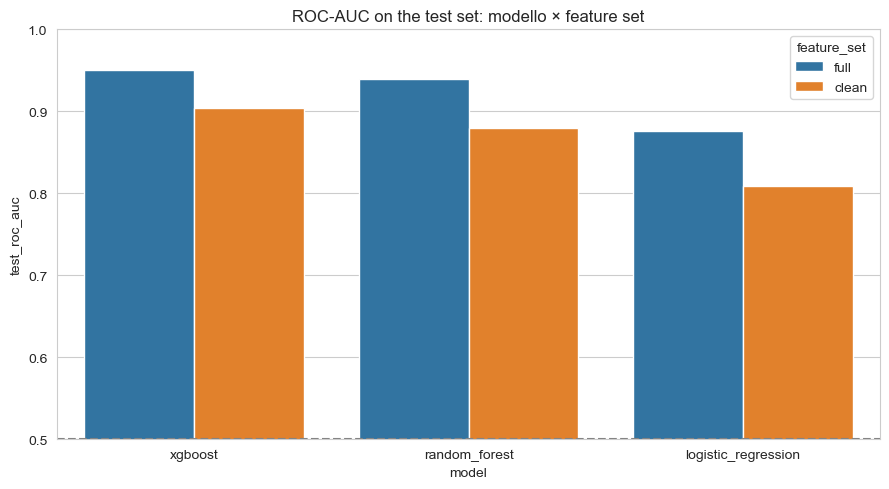

In [15]:
plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x="model", y="test_roc_auc", hue="feature_set")
plt.title("ROC-AUC on the test set: modello × feature set")
plt.ylim(0.5, 1.0)
plt.axhline(0.5, color="gray", linestyle="--", label="random baseline")
plt.tight_layout()
plt.show()

**Interpreting the comparison**: the ROC-AUC gap between `full` and `clean` for the same model
measures the extent to which `loan_grade`/`loan_int_rate` (the bank’s assessment) ‘explain’ the risk on their own,
compared to what the model learns from the raw customer data. A wide gap is normal
(the bank has additional internal information), but the `clean` model is the one that represents
the true added value for an individual analysis.

## 8. Feature importance of the best (clean) model

Best model on a ‘clean’ feature set: xgboost


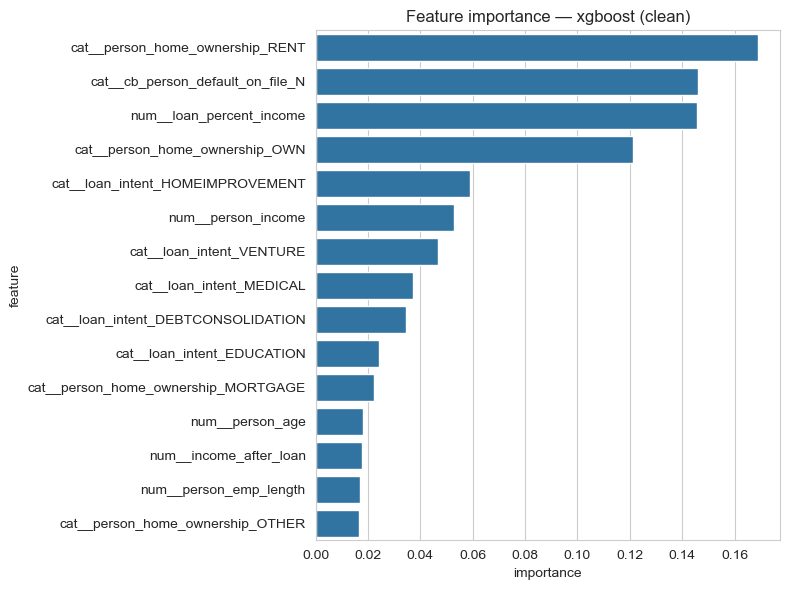

In [16]:
best_clean_key = summary[summary["feature_set"] == "clean"].iloc[0]
best_clean_name = best_clean_key["model"]
best_clean_model = all_results[f"{best_clean_name}__clean"]["model"]

print(f"Best model on a ‘clean’ feature set: {best_clean_name}")

# feature names after pre-processing (one-hot + numerical)
feature_names = best_clean_model.named_steps["prep"].get_feature_names_out()

if hasattr(best_clean_model.named_steps["clf"], "feature_importances_"):
    importances = best_clean_model.named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature")
    plt.title(f"Feature importance — {best_clean_name} (clean)")
    plt.tight_layout()
    plt.show()
else:
    print("The best model does not display feature_importances_ by default (e.g. Logistic Regression: see the coefficients).")

## 9. Saving the final model

Let’s save the `clean` model with the highest ROC-AUC

In [17]:
joblib.dump(best_clean_model, "../models/best_credit_risk_model.pkl")
print(f"Saved Model: {best_clean_name} (feature set: clean, test ROC-AUC: {all_results[f'{best_clean_name}__clean']['results']['test_roc_auc']:.4f})")

Saved Model: xgboost (feature set: clean, test ROC-AUC: 0.9041)


## 10. Conclusions

- The `clean` model represents a risk estimate based solely on the customer’s data,
  without relying on the judgement already expressed by the bank (`loan_grade`/`loan_int_rate`).
